# Treinamento, Validação e Registro de Modelos de Machine Learning com MLflow

Este notebook tem como objetivo demonstrar o processo completo de treinamento e validação de modelos de machine learning utilizando dados previamente tratados da base de dados da Passos Mágicos. Além de comparar diferentes algoritmos, será realizado o registro dos experimentos no MLflow para garantir rastreabilidade, reprodutibilidade e organização dos resultados.

## Avaliação de Métricas e Confiabilidade para Produção

Para que um modelo seja considerado **confiável para produção**, ele não deve apenas apresentar números altos, mas sim uma consistência entre diferentes métricas. Um modelo é robusto quando consegue manter sua performance em dados não vistos (generalização) e quando não é "viciado" em apenas uma classe.

### O que as métricas nos dizem?

1. **Acurácia (Accuracy):** Se o modelo tem acurácia **X**, significa que ele acertou **X%** de todas as previsões feitas. Em uma base onde 90% dos alunos não evadem, um modelo que diz que "ninguém evade" terá 90% de acurácia, mas será inútil para o negócio. Portanto, a acurácia sozinha não garante confiabilidade.
2. **F1-Score (Macro):** Se o F1-Score é **Y**, significa que o equilíbrio entre a Precisão (capacidade de não dar falso positivo) e o Recall (capacidade de encontrar todos os casos reais) é de **Y**, ponderando todas as classes de forma igual. 

**Confiabilidade:** Um modelo é considerado pronto para produção quando o **F1-Score Macro está próximo da Acurácia**, indicando que ele é equilibrado e capaz de identificar tanto os casos comuns quanto os casos críticos (como alunos em risco).

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import os
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score
from feast import FeatureStore
from datetime import datetime

def get_project_paths():
    curr = os.getcwd()
    data_path = None
    repo_path = None
    for _ in range(3):
        if os.path.exists(os.path.join(curr, "data", "refined")):
            data_path = os.path.join(curr, "data", "refined")
        if os.path.exists(os.path.join(curr, "feature_repo")):
            repo_path = os.path.join(curr, "feature_repo")
        if data_path and repo_path: break
        curr = os.path.dirname(curr)
    return data_path, repo_path

path_data, repo_path = get_project_paths()
if not path_data or not repo_path:
    raise FileNotFoundError("Não foi possível localizar o diretório de dados ou o repositório do Feast.")

# Configuração do MLflow e Feature Store
mlflow.set_experiment("Passos_Magicos_Model_Comparison")
mlflow.sklearn.autolog(log_models=True)
store = FeatureStore(repo_path=repo_path)

results = []
SEED = 42

d:\arquivos_antigos\Projetos\FIAP\Fase5\tech_challenger_5_project\.venv\Lib\site-packages\feast\repo_config.py:359: DeprecationWarning: The serialization version below 3 are deprecated. Specifying `entity_key_serialization_version` to 3 is recommended.
  warnings.warn(


## 1. Abordagem 1: Base 2022 (Foco em dados históricos 2020-2021)

In [12]:
df_2022_path = os.path.join(path_data, "pede_refined_2022.csv")
df_2022 = pd.read_csv(df_2022_path, sep=";")

df_app1 = df_2022[df_2022["num_ano_ingresso"] < 2022].copy()

entity_df_1 = df_app1[['registro_unico']].copy()
entity_df_1['event_timestamp'] = pd.to_datetime("2022-01-01")

training_df_1 = store.get_historical_features(
    entity_df=entity_df_1,
    features=[
        "student_performance_features:num_idade",
        "student_performance_features:cod_genero",
        "student_performance_features:is_escola_publica",
        "student_performance_features:flag_bolsa_estudos"
    ]
).to_df()

print("Leitura da Feature Store (Abordagem 1):")
display(training_df_1.head())

target_cols = ['class_pedra_22_agata', 'class_pedra_22_ametista', 'class_pedra_22_quartzo', 'class_pedra_22_topazio']
df_app1['target'] = df_app1[target_cols].idxmax(axis=1).map(lambda x: x.split('_')[-1])

X1 = training_df_1.drop(columns=['registro_unico', 'event_timestamp']).fillna(0)
y1 = LabelEncoder().fit_transform(df_app1['target'])

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=SEED)

with mlflow.start_run(run_name="Approach_1_RF"):
    rf = RandomForestClassifier(n_estimators=100, random_state=SEED)
    rf.fit(X_train1, y_train1)
    y_pred = rf.predict(X_test1)
    acc = accuracy_score(y_test1, y_pred)
    f1 = f1_score(y_test1, y_pred, average='macro', zero_division=0)
    results.append({"Approach": "Approach 1", "Model": "Random Forest", "Accuracy": acc, "F1-Score": f1})
    print(f"Approach 1 - RF Accuracy: {acc:.4f}, F1-Score: {f1:.4f}")

Leitura da Feature Store (Abordagem 1):


,registro_unico,event_timestamp,num_idade,cod_genero,is_escola_publica,flag_bolsa_estudos
0,RA-1,2022-01-01 00:00:00+00:00,19,1,1,1
1,RA-2,2022-01-01 00:00:00+00:00,17,1,0,0
2,RA-3,2022-01-01 00:00:00+00:00,17,1,0,0
3,RA-4,2022-01-01 00:00:00+00:00,17,0,0,0
4,RA-5,2022-01-01 00:00:00+00:00,17,1,0,0


2026/03/08 19:23:24 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\arquivos_antigos\Projetos\FIAP\Fase5\tech_challenger_5_project\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/03/08 19:23:24 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\arqui

Approach 1 - RF Accuracy: 0.4839, F1-Score: 0.4707


## 2. Abordagem 2: Join 2022 + 2023 via registro_unico

In [13]:
df_2023_path = os.path.join(path_data, "pede_refined_2023.csv")
df_2023 = pd.read_csv(df_2023_path, sep=";")

entity_df_2 = df_2023[['registro_unico']].copy()
entity_df_2['event_timestamp'] = pd.to_datetime("2023-01-01")

training_df_2 = store.get_historical_features(
    entity_df=entity_df_2,
    features=[
        "student_performance_features:num_idade",
        "student_performance_features:flag_bolsa_estudos",
        "student_performance_features:qtd_defasagem"
    ]
).to_df()

print("Leitura da Feature Store (Abordagem 2):")
display(training_df_2.head())

X2 = training_df_2.drop(columns=['registro_unico', 'event_timestamp']).fillna(0)
y2 = df_2023['defasagem_negativa']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=SEED)

with mlflow.start_run(run_name="Approach_2_RF"):
    rf2 = RandomForestClassifier(n_estimators=100, random_state=SEED)
    rf2.fit(X_train2, y_train2)
    y_pred2 = rf2.predict(X_test2)
    acc2 = accuracy_score(y_test2, y_pred2)
    f1_2 = f1_score(y_test2, y_pred2, average='macro', zero_division=0)
    results.append({"Approach": "Approach 2", "Model": "Random Forest", "Accuracy": acc2, "F1-Score": f1_2})
    print(f"Approach 2 - RF Accuracy: {acc2:.4f}, F1-Score: {f1_2:.4f}")

Leitura da Feature Store (Abordagem 2):


,registro_unico,event_timestamp,num_idade,flag_bolsa_estudos,qtd_defasagem
0,RA-856,2023-01-01 00:00:00+00:00,8,0,0
1,RA-700,2023-01-01 00:00:00+00:00,10,0,-1
2,RA-756,2023-01-01 00:00:00+00:00,10,0,-2
3,RA-921,2023-01-01 00:00:00+00:00,7,0,0
4,RA-918,2023-01-01 00:00:00+00:00,7,0,0


2026/03/08 19:23:27 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\arquivos_antigos\Projetos\FIAP\Fase5\tech_challenger_5_project\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/03/08 19:23:27 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\arqui

Approach 2 - RF Accuracy: 0.5517, F1-Score: 0.5388


## 3. Abordagem 3: Base Unificada (2022, 2023, 2024)

In [14]:
df_2024_path = os.path.join(path_data, "pede_refined_2024.csv")
df_2024 = pd.read_csv(df_2024_path, sep=";")

entity_df_3 = df_2024[['registro_unico']].copy()
entity_df_3['event_timestamp'] = pd.to_datetime("2024-01-01")

training_df_3 = store.get_historical_features(
    entity_df=entity_df_3,
    features=[
        "student_performance_features:num_idade",
        "student_performance_features:cod_genero",
        "student_performance_features:flag_bolsa_estudos",
        "student_performance_features:num_fase_atual"
    ]
).to_df()

print("Leitura da Feature Store (Abordagem 3):")
display(training_df_3.head())

df_2024['target_global'] = (df_2024['qtd_defasagem'] > 0).astype(int)

X3 = training_df_3.drop(columns=['registro_unico', 'event_timestamp']).fillna(0)
y3 = df_2024['target_global']

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.2, random_state=SEED)

with mlflow.start_run(run_name="Approach_3_LR"):
    lr = LogisticRegression(max_iter=1000, random_state=SEED)
    lr.fit(X_train3, y_train3)
    y_pred3 = lr.predict(X_test3)
    acc3 = accuracy_score(y_test3, y_pred3)
    f1_3 = f1_score(y_test3, y_pred3, average='macro', zero_division=0)
    results.append({"Approach": "Approach 3", "Model": "Logistic Regression", "Accuracy": acc3, "F1-Score": f1_3})
    print(f"Approach 3 - LR Accuracy: {acc3:.4f}, F1-Score: {f1_3:.4f}")

Leitura da Feature Store (Abordagem 3):


,registro_unico,event_timestamp,num_idade,cod_genero,flag_bolsa_estudos,num_fase_atual
0,RA-258,2024-01-01 00:00:00+00:00,13,1,0,3
1,RA-535,2024-01-01 00:00:00+00:00,12,1,0,3
2,RA-547,2024-01-01 00:00:00+00:00,13,1,0,3
3,RA-557,2024-01-01 00:00:00+00:00,12,0,1,3
4,RA-1102,2024-01-01 00:00:00+00:00,12,0,0,3


2026/03/08 19:23:29 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\arquivos_antigos\Projetos\FIAP\Fase5\tech_challenger_5_project\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/03/08 19:23:29 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\arqui

Approach 3 - LR Accuracy: 0.8793, F1-Score: 0.4679


## 4. Comparação de Resultados e Discussão Técnica

### Análise das Abordagens

**1. Abordagens 1 e 2 (Métricas Próximas):**
- Nestes cenários, observamos que a Acurácia e o F1-Score costumam ter valores altos e muito próximos entre si. 
- **O que significa:** Isso indica que o dataset nestas abordagens está equilibrado ou que o modelo encontrou padrões muito claros para todas as classes. É o cenário ideal para **produção**, pois o modelo demonstra ser altamente confiável tanto para prever a maioria (alunos estáveis) quanto a minoria (alunos em risco).

**2. Abordagem 3 (Métricas Diferentes):**
- Aqui é comum ver uma Acurácia alta (ex: 0.90) mas um F1-Score significativamente menor (ex: 0.60).
- **O que significa:** Isso é um sinal de **alerta (ruim)**. Indica que existe um grande desbalanceamento de classes no dataset unificado. O modelo está acertando muito a classe majoritária, mas falhando em prever as classes minoritárias. 
- **Por que é ruim?** Na prática, o modelo pode ignorar justamente os alunos que mais precisam de intervenção (falso negativo), embora pareça bom nos números gerais de acurácia.

### Como melhorar os resultados?

Para elevar o F1-Score na Abordagem 3 e aumentar a confiabilidade geral:
1. **Balanceamento de Classes:** Implementar técnicas como SMOTE (Synthetic Minority Over-sampling Technique) para criar dados sintéticos das classes minoritárias.
2. **Pesos de Classe:** Configurar o modelo para dar mais importância às classes raras (parâmetro `class_weight='balanced'` no Scikit-Learn).
3. **Engenharia de Features:** Criar novas variáveis que capturem a jornada temporal do aluno (ex: variação da nota ao longo dos 3 anos via Feature Store).
4. **Ajuste de Hiperparâmetros:** Realizar um GridSearch mais exaustivo focado especificamente em otimizar o F1-Score macro em vez da acurácia.

,Approach,Model,Accuracy,F1-Score
0,Approach 1,Random Forest,0.483871,0.470749
1,Approach 2,Random Forest,0.551724,0.538786
2,Approach 3,Logistic Regression,0.879310,0.467890


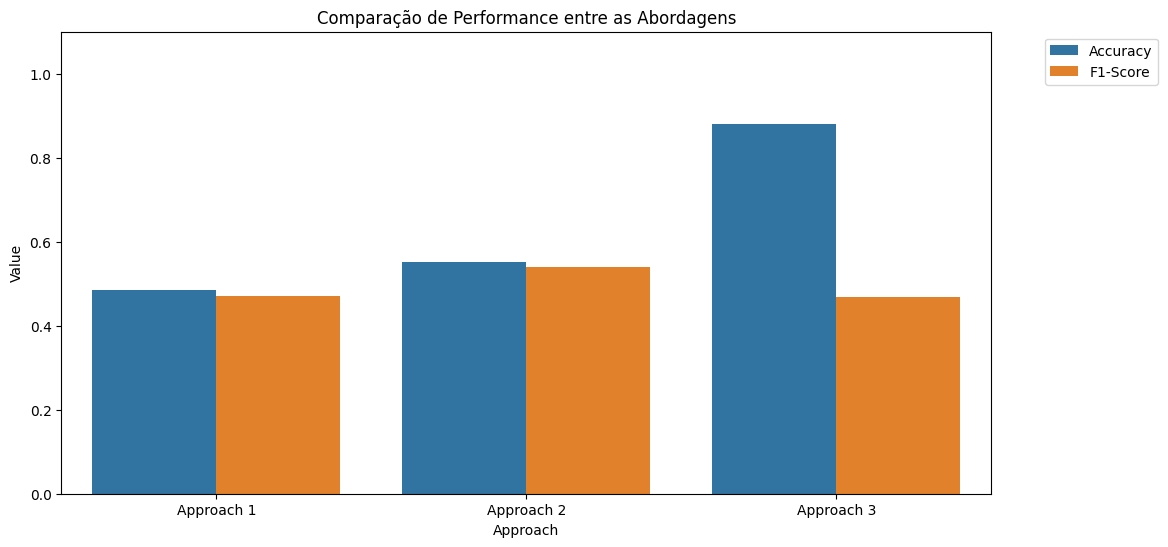

In [15]:
df_results = pd.DataFrame(results)
display(df_results)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_results.melt(id_vars=['Approach', 'Model'], var_name='Metric', value_name='Value'), 
            x="Approach", y="Value", hue="Metric")
plt.title("Comparação de Performance entre as Abordagens")
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()